# Spaceship Titanic

## 1. 개요
- 승객 개인 데이터들을 활용하여 우주선 충돌시 다른 차원으로 승객이 이동했는 지 여부를 예측하는 이진 분류 과제이다.
- 데이터 전처리 및 하이퍼 파라미터 최적화를 통해 캐글 Public Score 0.805이상 달성

## 2. 목차


### 라이브러리 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# 데이터 경로 설정
train_data_path = join('./data', 'train.csv')
test_data_path = join('./data', 'test.csv')

# 데이터 로드
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

In [ ]:
# train 데이터 확인
print('train data dim : {}'.format(train.shape))
train.head()

train data dim : (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# test 데이터 확인
print('test data dim : {}'.format(test.shape))
test.head()

test data dim : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


### 데이터 확인

In [ ]:
# 결측치 확인을 위한 info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


<Axes: >

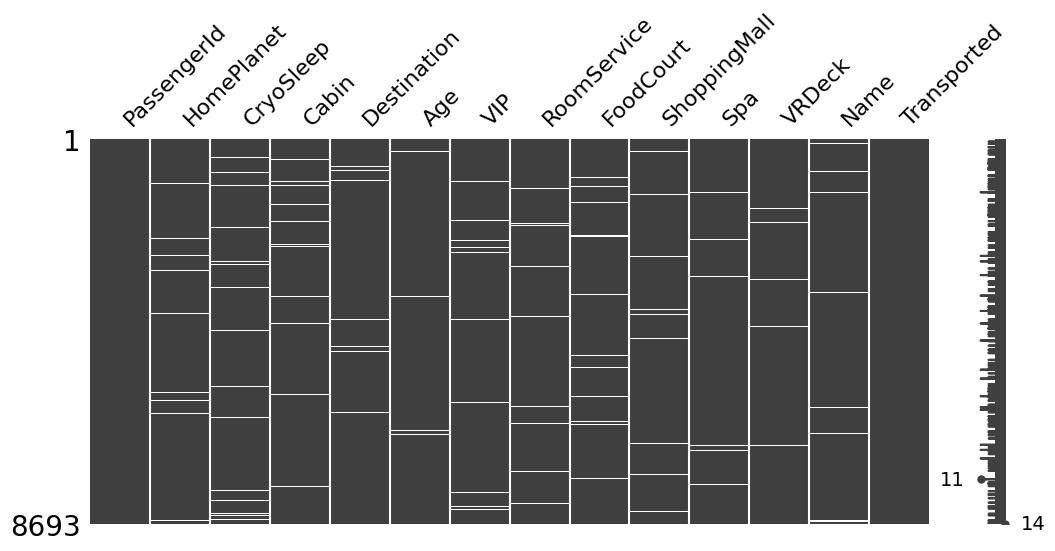

In [ ]:
# missingno를 통한 결측치 확인
msno.matrix(train, figsize = (12,5))

In [ ]:
# 실제 결측치 개수 확인
train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   str    
 1   HomePlanet    4190 non-null   str    
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   str    
 4   Destination   4185 non-null   str    
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   str    
dtypes: float64(6), object(2), str(5)
memory usage: 434.5+ KB


In [9]:
test.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [ ]:
# 수치형 데이터 분석
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


나이 평균은 29세, 편의시설은 50%가 0이므로 대다수 이용하지 않으나 max값이 매우 크다

In [ ]:
# 범주형 데이터 분석
train.describe(include=['O'])

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Elaney Webstephrey
freq,1,4602,5439,8,5915,8291,2


HomePlanet과 Destination은 3개, CryoSleep은 2개의 범주만 있다
Cabin은 3개로 나누어 분류하고 Name은 버려도 될듯하다

In [12]:
test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [13]:
test.describe(include=['O'])

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,4277,4190,4184,4177,4185,4184,4183
unique,4277,3,2,3265,3,2,4176
top,0013_01,Earth,False,G/160/P,TRAPPIST-1e,False,Berta Barnolderg
freq,1,2263,2640,8,2956,4110,2


test도 train과 동일

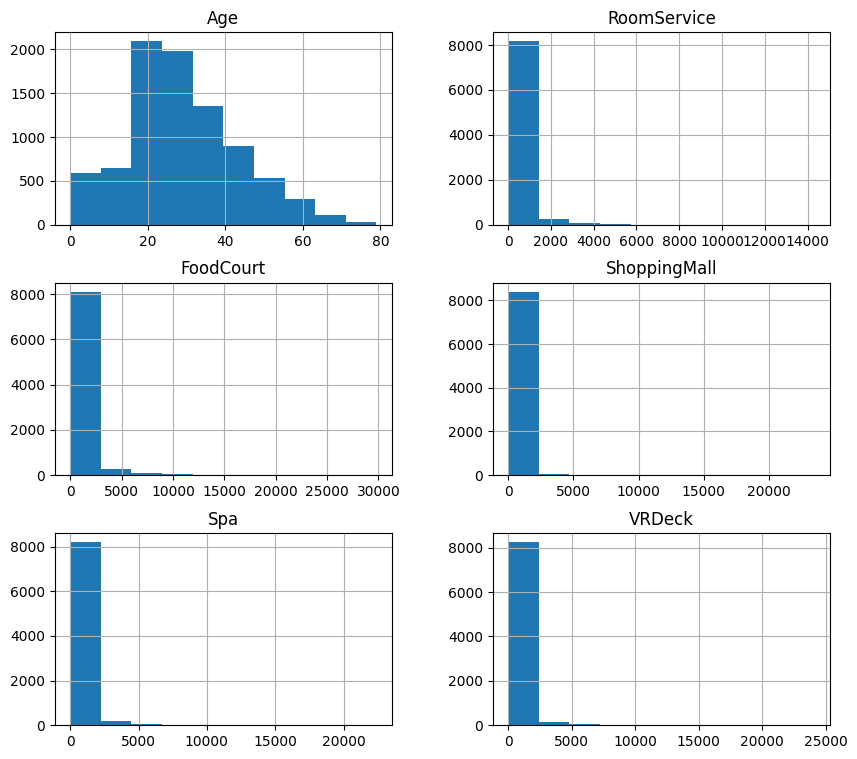

In [ ]:
# 수치형 데이터 시각화
train.hist(figsize=(10, 9))
plt.show()

20~40대가 많고 서비스들은 대부분 0이다.

In [15]:
# 수치형들은 중앙값으로 전처리
train['Age'] = train['Age'].fillna(train['Age'].median())
train['RoomService'] = train['RoomService'].fillna(train['RoomService'].median())
train['FoodCourt'] = train['FoodCourt'].fillna(train['FoodCourt'].median())
train['ShoppingMall'] = train['ShoppingMall'].fillna(train['ShoppingMall'].median())
train['Spa'] = train['Spa'].fillna(train['Spa'].median())
train['VRDeck'] = train['VRDeck'].fillna(train['VRDeck'].median())

# 범주형들은 최빈값으로 전처리
train['CryoSleep'] = train['CryoSleep'].fillna(0)
train['VIP'] = train['VIP'].fillna(0)
train['HomePlanet'] = train['HomePlanet'].fillna(train['HomePlanet'].mode()[0])
train['Cabin'] = train['Cabin'].fillna(train['Cabin'].mode()[0])
train['Destination'] = train['Destination'].fillna(train['Destination'].mode()[0])

수치형들은 이상치에 영향을 덜받는 중앙값으로 범주형은 최빈값으로 처리하였다

In [16]:
# Cabin 분리
cabin = train['Cabin'].apply(lambda x:x.split('/'))
train['Cab_deck'] = cabin.apply(lambda x:x[0])
train['Cab_num'] = cabin.apply(lambda x:float(x[1]))
train['Cab_side'] = cabin.apply(lambda x:x[2])

Cabin이라는 통합 데이터를 3개로 쪼갠다

In [17]:
# 필요없는 열 제거
train.drop(['PassengerId', 'Cabin', 'Name'], axis = 1, inplace = True)

의미없다 생각한 PassengerId와 Name을 버리고 쪼개기전 데이터인 Cabin도 버린다

In [18]:
# type을 object에서 int로 통일
train['CryoSleep'] = train['CryoSleep'].astype(int)
train['VIP'] = train['VIP'].astype(int)

In [ ]:
# 결측치 제거 확인
train.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Cab_deck        0
Cab_num         0
Cab_side        0
dtype: int64

In [ ]:
# 데이터 및 타입 확인
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   str    
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   str    
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  Cab_deck      8693 non-null   str    
 12  Cab_num       8693 non-null   float64
 13  Cab_side      8693 non-null   str    
dtypes: bool(1), float64(7), int64(2), str(4)
memory usage: 891.5 KB


### 데이터 전처리 및 상관관계 분석

In [ ]:
# VIP 여부에 따라 Transported의 평균을 비교한다
train[['VIP', 'Transported']].groupby(['VIP'], as_index=False).mean().sort_values(by='Transported')

,VIP,Transported
1,1,0.381910
0,0,0.506475


VIP인 사람 중 38%가 이동하고 아닌사람 중 50%가 이동했다

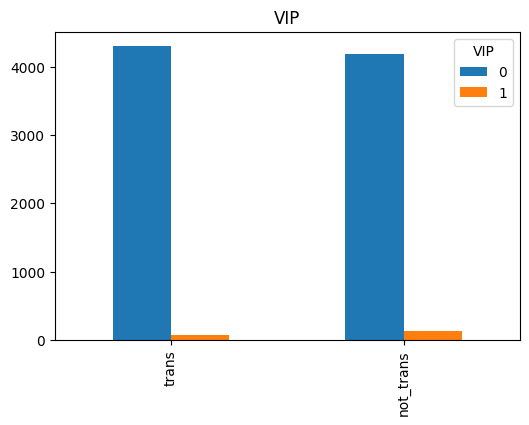

In [ ]:
# Transported한 승객중 VIP 여부별 승객 수
trans = train[train['Transported']==1]['VIP'].value_counts()
# Transported하지 못한 승객중 VIP 여부별 승객 수
not_trans = train[train['Transported']==0]['VIP'].value_counts()

# dataframe으로 시각화
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('VIP')
plt. show()

In [ ]:
# 파이를 통해 그래프를 표기하는 코드이다.
# 여러번 반복하는데 코드가 길어 폐기하고 남긴다.
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# axes[0].pie(trans, 
#            labels=['General', 'VIP'], 
#            autopct='%1.1f%%',
#            startangle=90,
#            colors=['#abcdef', '#ff9090'],
#            explode=(0, 0.1),
#            textprops={'fontsize':14})
# axes[0].set_title('VIP Ratio among Transported', fontsize=20)
# axes[1].pie(not_trans, 
#            labels=['General', 'VIP'], 
#            autopct='%1.1f%%', 
#            startangle=90, 
#            colors=['#abcdef', "#ff9090"], 
#            explode=(0, 0.1),
#            textprops={'fontsize':14})
# axes[1].set_title('VIP Ratio among Non-Transported', fontsize=20)

# # 그래프 출력
# plt.tight_layout()
# plt.show()

VIP 유무가 Transported와 상관관계에 있어보이진 않았다
따지자면 이동하지않은 VIP의 비율이 좀더 높았다

In [ ]:
# 이번엔 CryoSleep 여부를 통해 비교
train[['CryoSleep', 'Transported']].groupby(['CryoSleep'], as_index=False).mean().sort_values(by='Transported')

,CryoSleep,Transported
0,0,0.335042
1,1,0.817583


CryoSleep한 사람은 82% 안한 사람은 34%이다

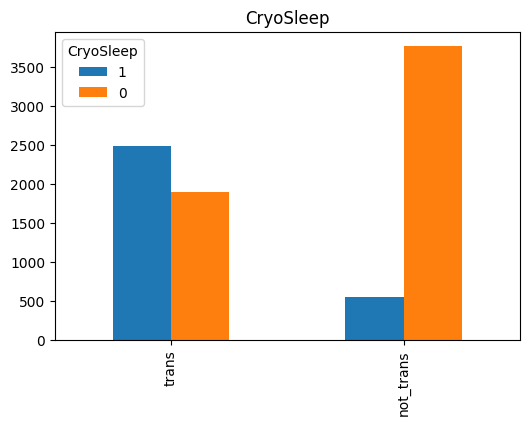

In [24]:
trans = train[train['Transported']==1]['CryoSleep'].value_counts()
not_trans = train[train['Transported']==0]['CryoSleep'].value_counts()
df_vip = pd.DataFrame([trans, not_trans])
df_vip.index = ['trans', 'not_trans']
df_vip.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('CryoSleep')
plt. show()

CryoSleep한 사람중 82%가 trans하고 trans하지않은 비중이 CryoSleep하지않은 사람이 압도적인 것으로 보아 상관관계가 있어보인다

In [ ]:
# HomePlanet 위치를 통해 비교
train[['HomePlanet', 'Transported']].groupby(['HomePlanet'], as_index=False).mean().sort_values(by='Transported')

,HomePlanet,Transported
0,Earth,0.427649
2,Mars,0.523024
1,Europa,0.658846


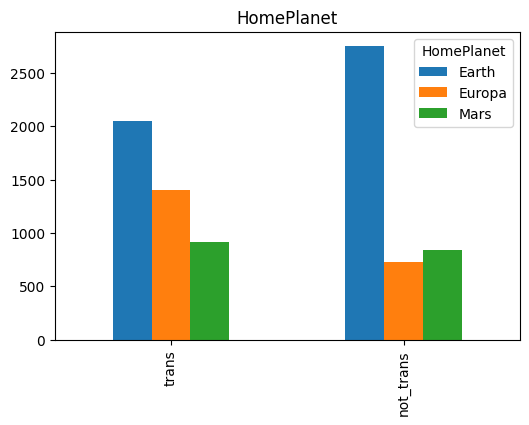

In [26]:
trans = train[train['Transported']==1]['HomePlanet'].value_counts()
not_trans = train[train['Transported']==0]['HomePlanet'].value_counts()
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('HomePlanet')
plt. show()

출발지는 지구가 많으나 trans비율은 가장 낮고 화성과 유로파는 절반이상이 trans했다
출발지별로 10퍼씩 차이나는 것으로 보아 상관관계가 있어보이긴한다

In [ ]:
# Destination 위치를 통해 비교
train[['Destination', 'Transported']].groupby(['Destination'], as_index=False).mean().sort_values(by='Transported')

,Destination,Transported
2,TRAPPIST-1e,0.472199
1,PSO J318.5-22,0.503769
0,55 Cancri e,0.610000


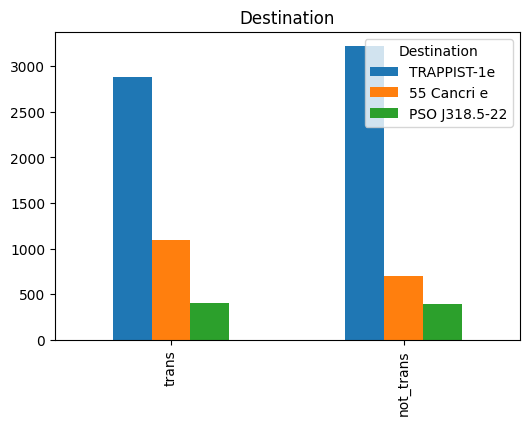

In [28]:
trans = train[train['Transported']==1]['Destination'].value_counts()
not_trans = train[train['Transported']==0]['Destination'].value_counts()
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('Destination')
plt. show()

Destination은 보통 50퍼센트로 도착하고 55 Cancri e만 10퍼 높았다
다 비슷한 것으로보아 상관관계는 낮아보인다

In [29]:
# 연령을 연령대로 변환
train['Age'] = (train['Age'] // 10) * 10

In [ ]:
# 연령대를 통해 비교
train[['Age', 'Transported']].groupby(['Age'], as_index=False).mean().sort_values(by='Transported')

,Age,Transported
7,70.0,0.434783
3,30.0,0.458790
2,20.0,0.471268
6,60.0,0.475962
5,50.0,0.493716
4,40.0,0.506679
1,10.0,0.532792
0,0.0,0.711340


0~10세일때 trans할 확률이 유난히 높아보인다

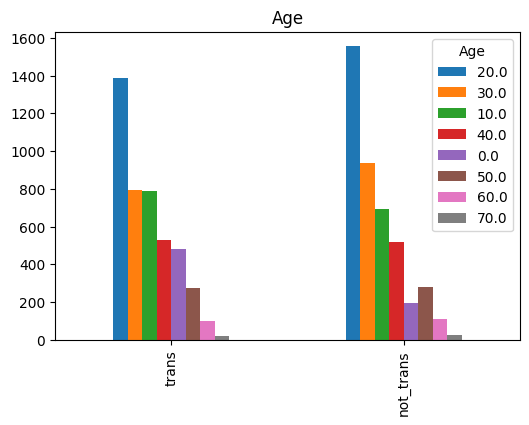

In [31]:
trans = train[train['Transported']==1]['Age'].value_counts()
not_trans = train[train['Transported']==0]['Age'].value_counts()
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('Age')
plt. show()

20~30대가 많고 0~10대가 Transported한 비율이 높다   
상관관계가 있어보인다

In [ ]:
# deck 위치에 따라 비교
train[['Cab_deck', 'Transported']].groupby(['Cab_deck'], as_index=False).mean().sort_values(by='Transported')

,Cab_deck,Transported
7,T,0.200000
4,E,0.357306
3,D,0.433054
5,F,0.439871
0,A,0.496094
6,G,0.515228
2,C,0.680054
1,B,0.734275


B, C가 trans한 비율이 많이 높아보인다

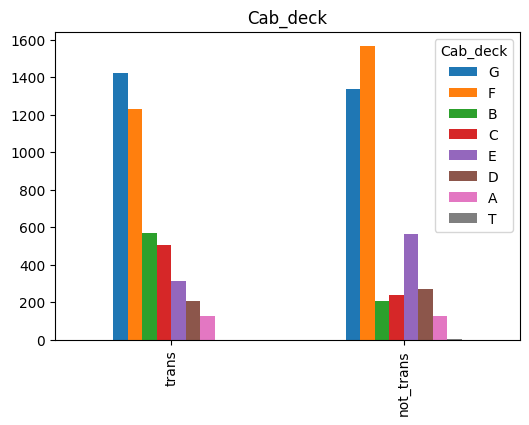

In [35]:
trans = train[train['Transported']==1]['Cab_deck'].value_counts()
not_trans = train[train['Transported']==0]['Cab_deck'].value_counts()
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('Cab_deck')
plt. show()

G, F의 수가 많고  B, C가 Transported한 비율이 높다   
알파벳별로 차이가 있는 것으로 보아 상관관계가 있어보인다

In [ ]:
# side 방향에 따라 비교
train[['Cab_side', 'Transported']].groupby(['Cab_side'], as_index=False).mean().sort_values(by='Transported')

,Cab_side,Transported
0,P,0.451260
1,S,0.552708


Starboard에 있을때 trans될 확률이 높아보인다

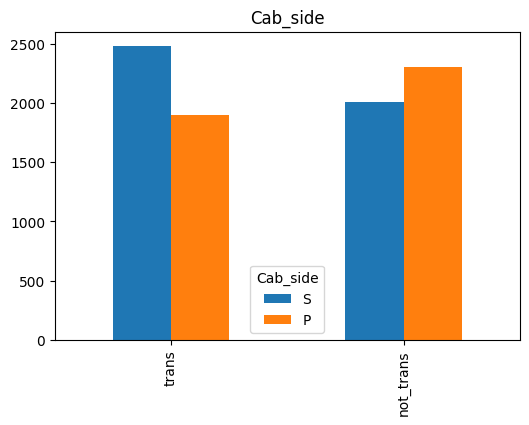

In [37]:
trans = train[train['Transported']==1]['Cab_side'].value_counts()
not_trans = train[train['Transported']==0]['Cab_side'].value_counts()
df = pd.DataFrame([trans, not_trans])
df.index = ['trans', 'not_trans']
df.plot(kind='bar', stacked=False, figsize=(6,4))
plt.title('Cab_side')
plt. show()

S에 있을때 P에 있을때보다 Transported된 수가 많다

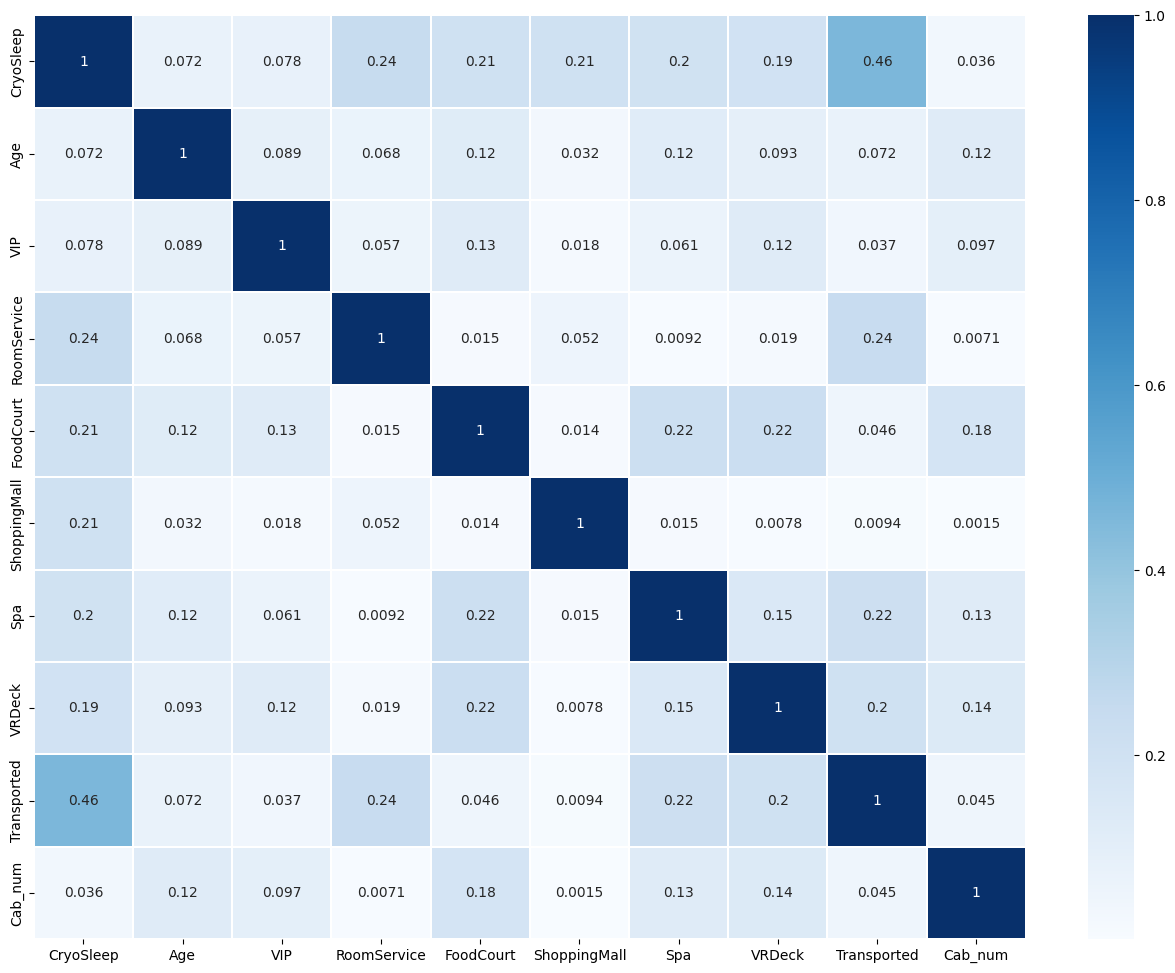

In [ ]:
# 히트맵을 통해 수치형 데이터의 상관관계 비교
plt.figure(figsize = (16, 12))
x = sns.heatmap(abs(train.corr(numeric_only=True)), cmap = 'Blues', linewidths = '0.1',annot = True)

그나마 CryoSleep이 0.46으로 상관관계가 있음을 볼 수 있다
그 뒤론 RoomService, FoodCount등이 0.24이하로 뒤를 따른다

### One Hot Encoding

In [ ]:
# feature만 input_data에 저장
input_data = train.drop(['Transported'], axis = 1)
# one hot encoding을 진행해 encoding_data에 저장
encoding_data = pd.get_dummies(input_data)
encoding_data.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Cab_num', 'HomePlanet_Earth', 'HomePlanet_Europa',
       'HomePlanet_Mars', 'Destination_55 Cancri e',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Cab_deck_A',
       'Cab_deck_B', 'Cab_deck_C', 'Cab_deck_D', 'Cab_deck_E', 'Cab_deck_F',
       'Cab_deck_G', 'Cab_deck_T', 'Cab_side_P', 'Cab_side_S'],
      dtype='str')

In [ ]:
# 다시 Transported를 encoding된 데이터와 결합
analysis = pd.merge(encoding_data, train['Transported'], left_index = True, right_index = True)

### 데이터 확인

Transported와 다른 feature간 상관관계 및 분포를 비교하기 위해  pairplot을 통해 시각화하였다

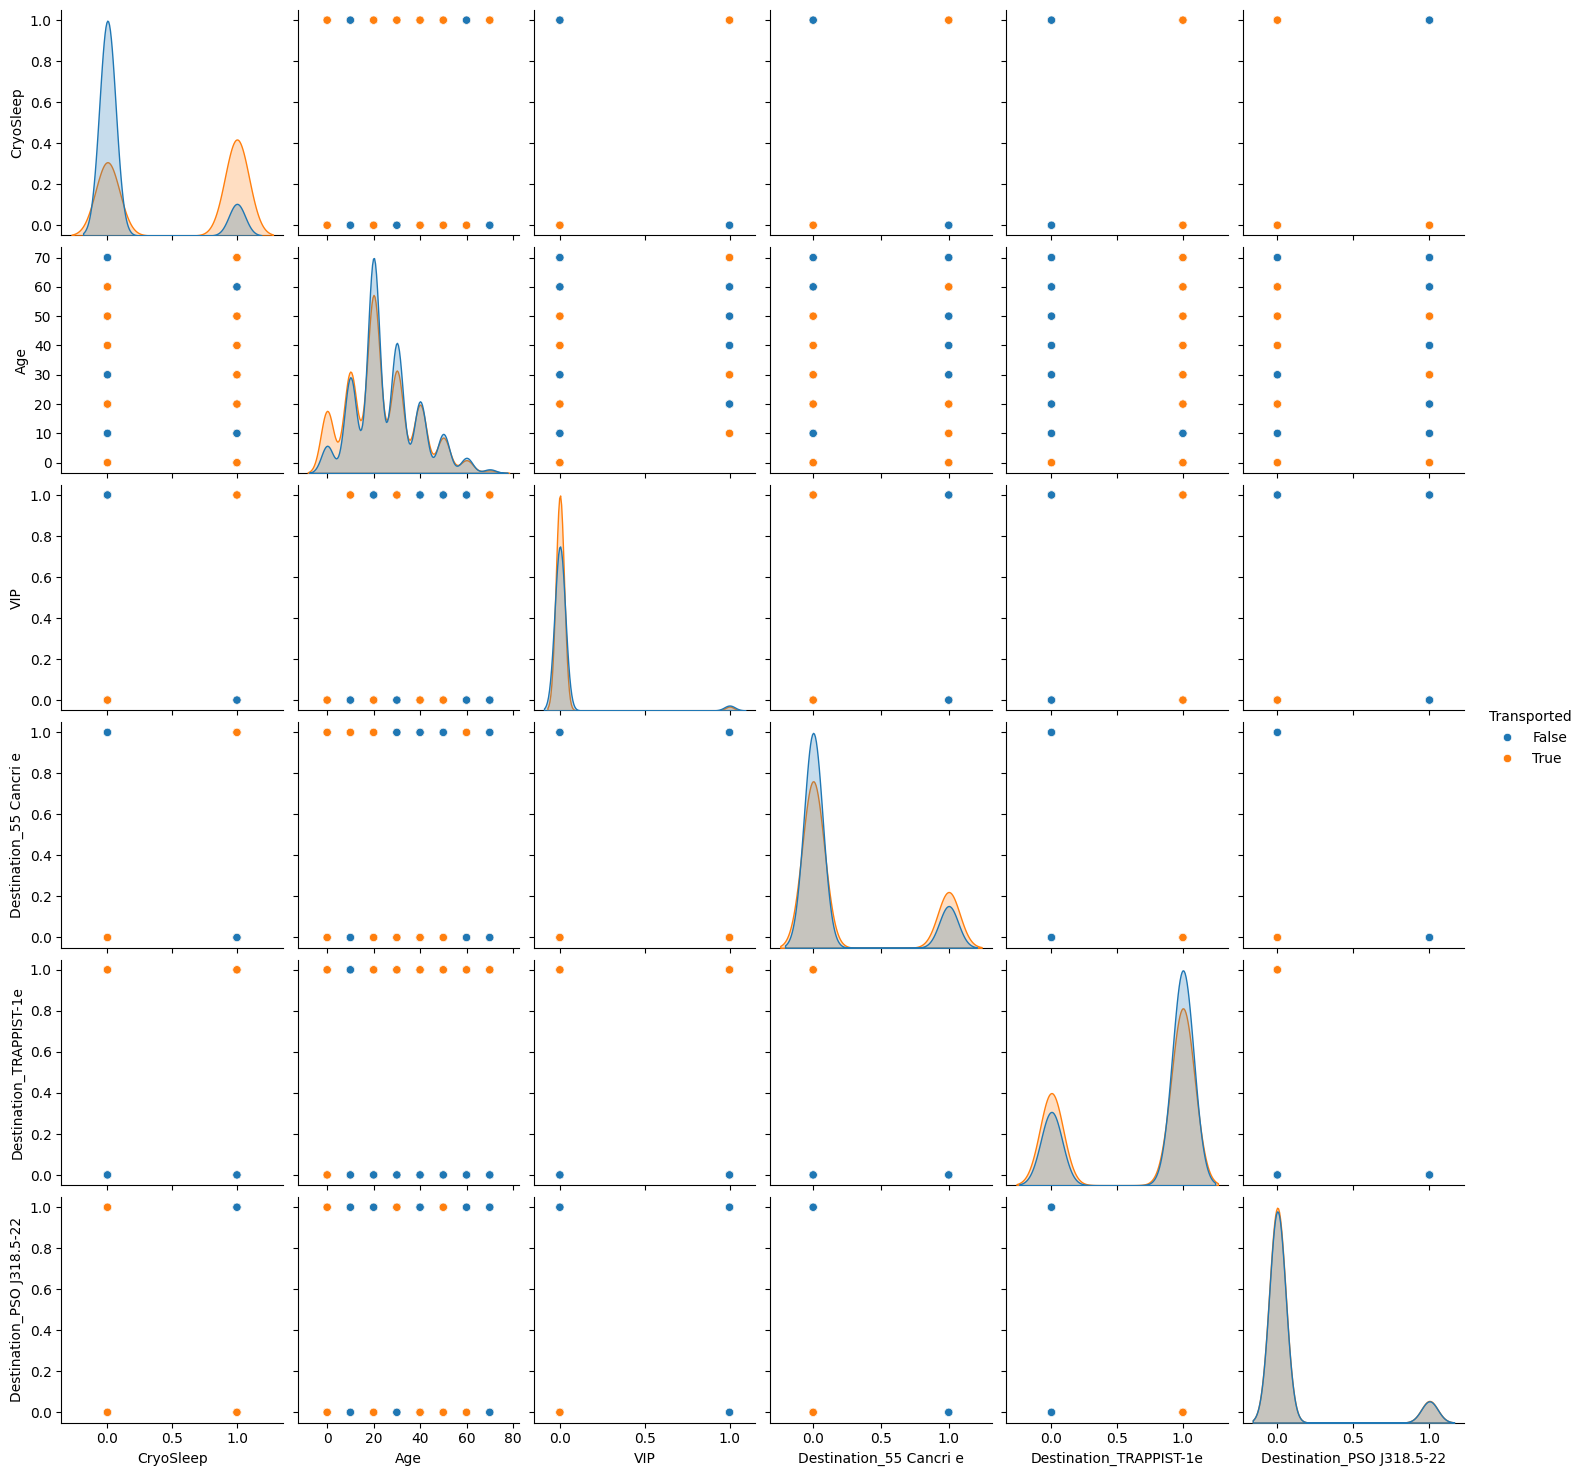

In [41]:
sns.pairplot(analysis[['CryoSleep','Age','VIP','Destination_55 Cancri e', 'Destination_TRAPPIST-1e', 'Destination_PSO J318.5-22', 'Transported']], hue = 'Transported', markers = ['o',])
plt.show()

'VIP'는 1인 값이 거의 없다   
'Destination_PSO J318.5-22' 가 거의 동일하다

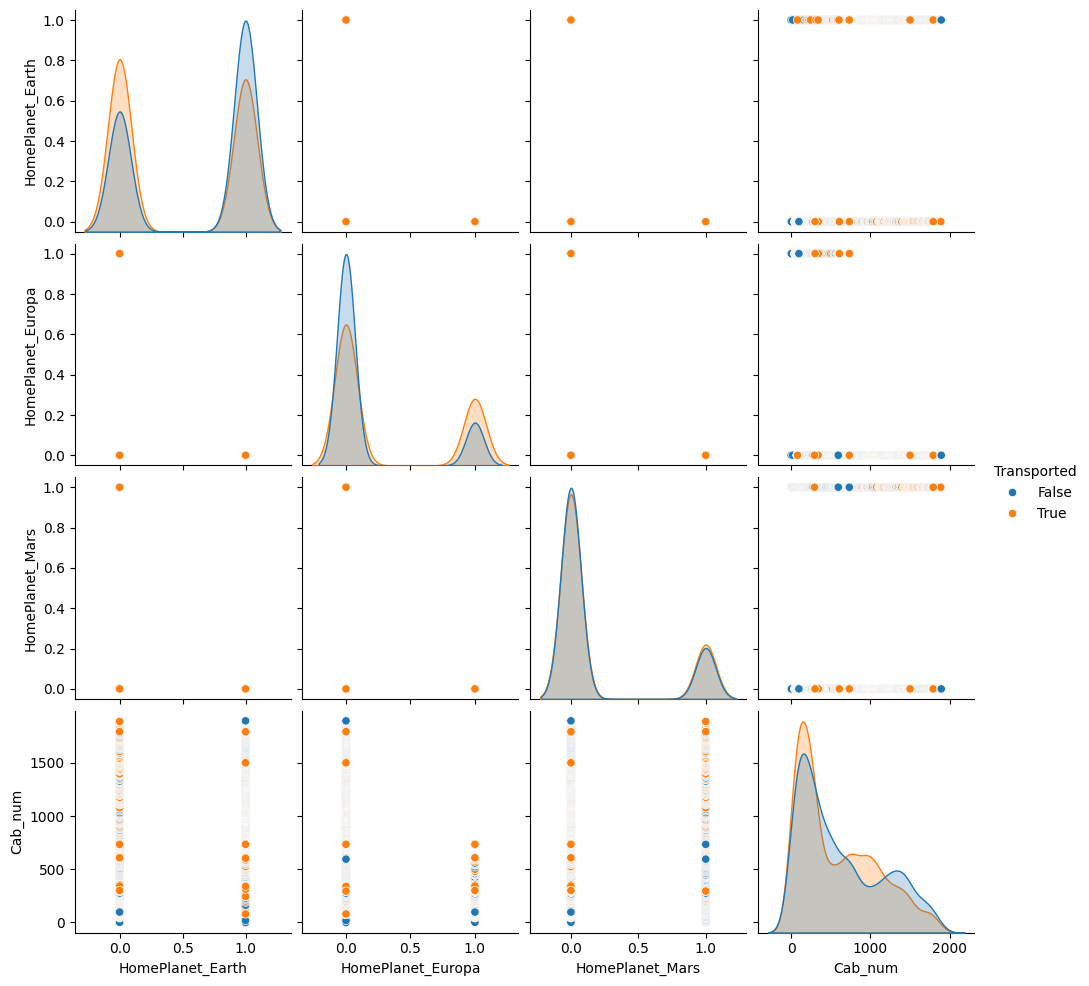

In [42]:
sns.pairplot(analysis[['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Cab_num', 'Transported']], hue = 'Transported', markers = ['o',])
plt.show()

'HomePlanet_Mars' 가 거의 동일하다

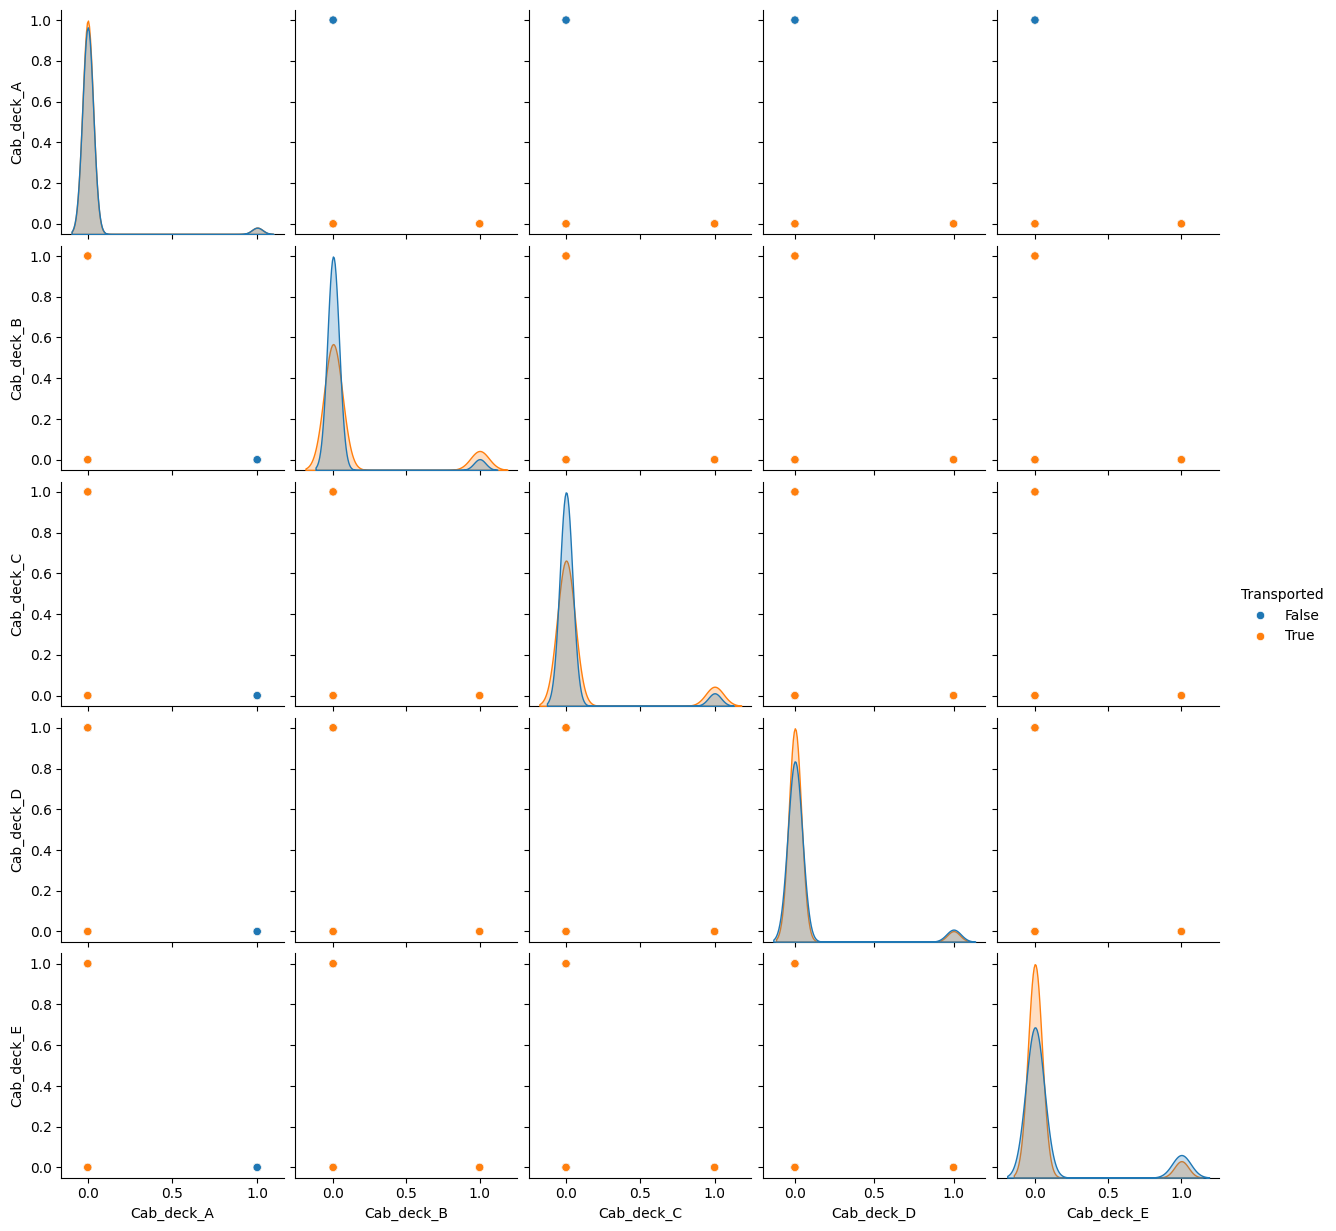

In [44]:
sns.pairplot(analysis[['Cab_deck_A','Cab_deck_B', 'Cab_deck_C', 'Cab_deck_D', 'Cab_deck_E', 'Transported']], hue = 'Transported', markers = ['o',])
plt.show()

'Cab_deck_A'가 거의 동일하다   
'Cab_deck_C'는 'Cab_deck_B'와 유사하다   
'Cab_deck_D'는 'Cab_deck_E'와 비슷하나 모수가 적다   

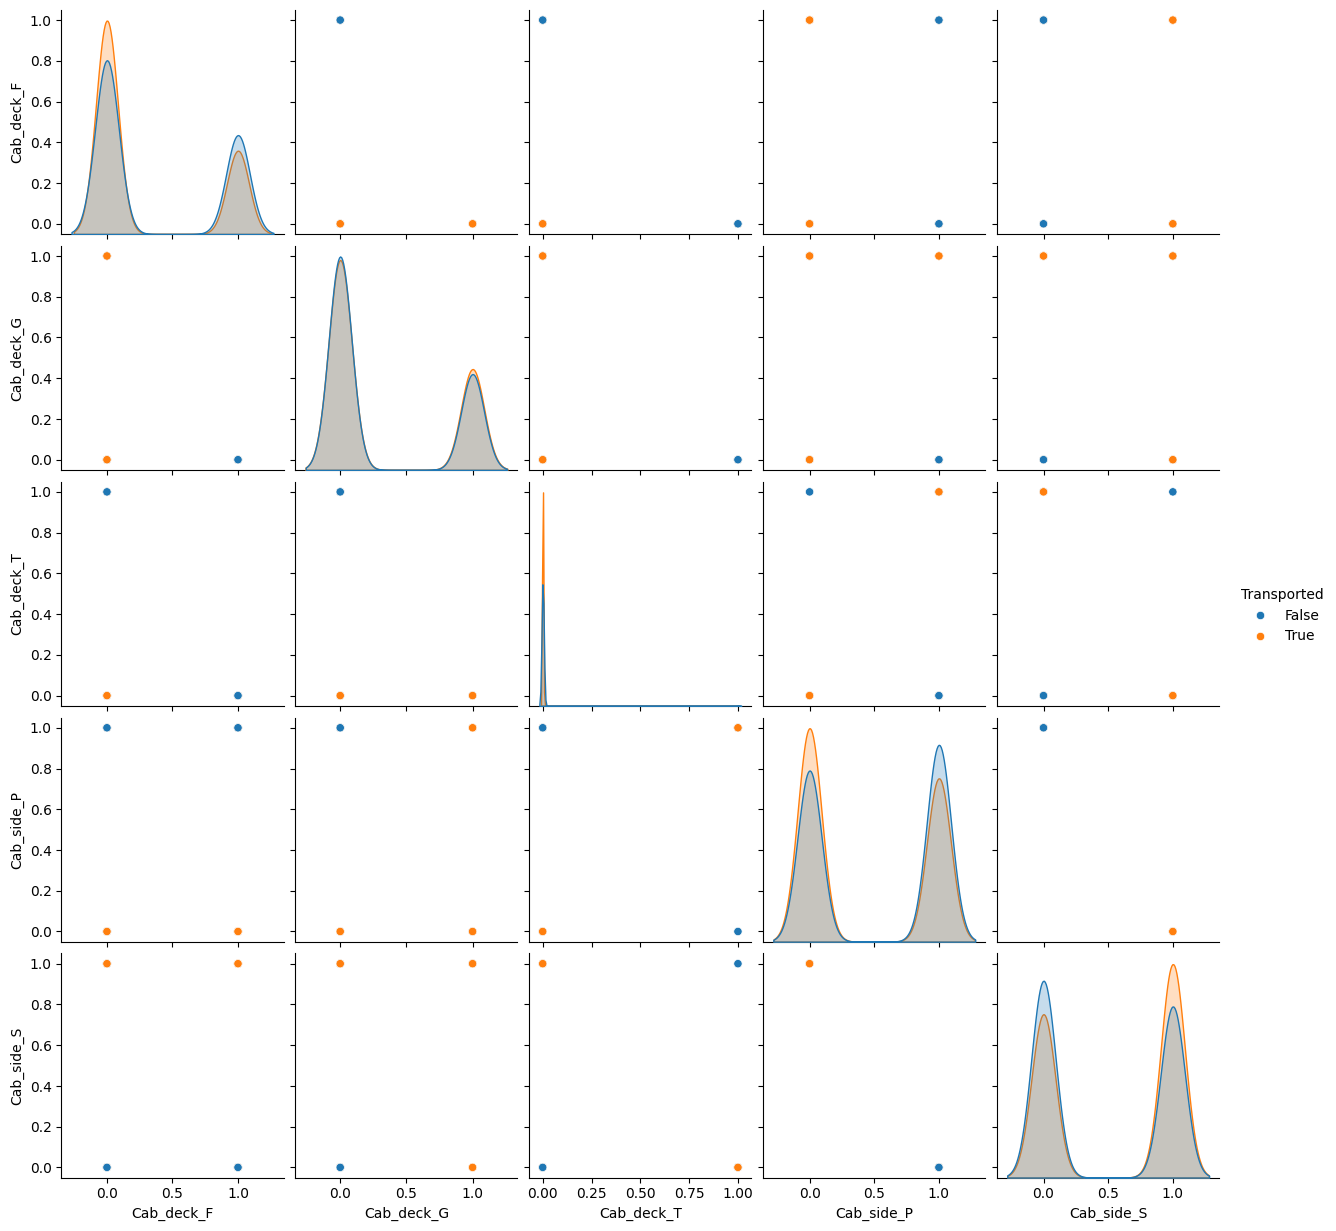

In [45]:
sns.pairplot(analysis[['Cab_deck_F','Cab_deck_G', 'Cab_deck_T', 'Cab_side_P', 'Cab_side_S', 'Transported']], hue = 'Transported', markers = ['o',])
plt.show()

'Cab_deck_G'는 거의 동일하다   
'Cab_deck_T'는 1인 데이터가 없고 모수가 적어보인다

**결론**   
'VIP', 'Destination_PSO J318.5-22', 'HomePlanet_Mars', 'Cab_deck_A', 'Cab_deck_C', 'Cab_deck_D', 'Cab_deck_G', 'Cab_deck_T'는 필요없는 feature다

In [ ]:
# target 열 분리
y = train['Transported']
# 불필요한 feature 제거
train = encoding_data.drop(['VIP', 'Destination_PSO J318.5-22', 'HomePlanet_Mars', 'Cab_deck_A', 'Cab_deck_C', 'Cab_deck_D', 'Cab_deck_G', 'Cab_deck_T'], axis=1)

### 모델 학습

In [ ]:
# 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(train, y, test_size = 0.3, random_state= 0)

In [ ]:
# 하이퍼 파라미터 탐색 그리드
param_grid = { 'n_estimators' : [200, 300, 400, 500, 600],
           'max_depth' : [6, 8, 10, 12, 16],
           'min_samples_leaf' : [2, 4, 8, 12, 16],
           'min_samples_split' : [4, 8, 12, 16, 20]
            }

In [ ]:
# RandomForestClassifier 모델 생성
model = RandomForestClassifier(random_state = 5, n_jobs = -1)

# GridSearchCV 객체 생성
grid_cv = GridSearchCV(model, param_grid=param_grid, cv=5, n_jobs=5)

# 하이퍼 파라미터 튜닝
grid_cv.fit(x_train, y_train)

# 최적 결과 출력 
print(grid_cv.best_params_)
print(grid_cv.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 12, 'n_estimators': 500}
0.8032867707477405


In [ ]:
# 튜닝된 하이퍼 파라미터로 모델 생성
model = RandomForestClassifier(n_estimators = 500, random_state = 2026, max_depth = 10, min_samples_leaf = 2, min_samples_split = 12, oob_score = True)
# 모델 학습
model.fit(x_train,y_train)
# 최종 예측 수행
pred = model.predict(x_test)

# 성능 지표 확인
print(model.score(x_train, y_train))
print(model.score(x_test, y_test))
print(model.oob_score_)

0.8499589153656533
0.8021472392638037
0.8013147082990961


### Test data 가공

In [55]:
test.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [ ]:
test['Age'] = test['Age'].fillna(test['Age'].median())
test['RoomService'] = test['RoomService'].fillna(test['RoomService'].median())
test['FoodCourt'] = test['FoodCourt'].fillna(test['FoodCourt'].median())
test['ShoppingMall'] = test['ShoppingMall'].fillna(test['ShoppingMall'].median())
test['Spa'] = test['Spa'].fillna(test['Spa'].median())
test['VRDeck'] = test['VRDeck'].fillna(test['VRDeck'].median())

test['CryoSleep'] = test['CryoSleep'].fillna(0)
test['VIP'] = test['VIP'].fillna(0)
test['HomePlanet'] = test['HomePlanet'].fillna(test['HomePlanet'].mode()[0])
test['Cabin'] = test['Cabin'].fillna(test['Cabin'].mode()[0])
test['Destination'] = test['Destination'].fillna(test['Destination'].mode()[0])

cabin = test['Cabin'].apply(lambda x:x.split('/'))
test['Cab_deck'] = cabin.apply(lambda x:x[0])
test['Cab_num'] = cabin.apply(lambda x:float(x[1]))
test['Cab_side'] = cabin.apply(lambda x:x[2])

test.drop(['PassengerId', 'Cabin', 'Name'], axis = 1, inplace = True)

test['CryoSleep'] = test['CryoSleep'].astype(int)
test['VIP'] = test['VIP'].astype(int)

encoding_test_data = pd.get_dummies(test)
test = encoding_test_data.drop(['VIP', 'Destination_PSO J318.5-22', 'HomePlanet_Mars', 'Cab_deck_A', 'Cab_deck_C', 'Cab_deck_D', 'Cab_deck_G', 'Cab_deck_T'], axis=1)

In [ ]:
# 최종 예측 수행
prediction = model.predict(test)

### 제출 csv 파일 생성

In [59]:
submission_path = join('./data', 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission['Transported'] = prediction
submission.to_csv('./data/SpaceShip_2.csv', index=False)

![](./spaceship_result.png)

## 결론 및 회고
이번엔 베이스라인이 존재하지않아 지난번 코드의 흐름을 따라 작성하였다.   
데이터 분석 - 데이터 전처리 - 모델 튜닝 - 최종 예측이라는 큰틀에서 코드를 수행하였고 이번엔 데이터 분석에 좀 더 큰 신경을 썼다.   
각 feature와 target간 관계를 먼저 barplot의 형태를 통해 확인하고 관계를 예측해보고 pairplot을 통해 의미없는 feature들을 걸러볼 수 있었다.   
모델 튜닝을 하면서는 GridSearchCV를 돌리는데 파라미터가 늘어나다보니 시간이 오래걸렸지만 그만큼 튜닝이 잘된 것같다.   
최초 제출 떄는 validation set을 20%만 사용했는데 30%로 더 크게하고 파라미터를 재조정하니 성능이 향상된 것을 볼 수 있었다.   
다만 이번에도 feature들을 다루긴했지만 이미 존재하는 feature들을 나누고 one hot encoding을 할 뿐이였지 파생 feature들을 다뤄 본 것은 아니라는 점이 아쉽게 느껴졌다.   
그리고 데이터를 처리하기 위해 여러 시각화 도구를 사용해보았는데 pairplot을 통해 보는 것은 새로운 느낌이였다.   
머신러닝 관련 글을 볼 때 이게 무슨 데이터지? 라는 생각을 했었는데 의미가 없는 데이터, 서로 유사한 데이터들을 거르기 위해 사용하면 전처리가 편해지는 것같았다.
마지막으로 모델은 ai한테 추천받아 RandomClassifier를 사용했는데 이것도 LGBM을 사용하면 더 좋은 성능이 나왔을 지 궁금하다.